In [1]:
# monter drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Appareil utilisé : cuda
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Colonnes : ['id', 'title', 'text', 'source', 'label', 'url', 'has_text', 'text_length']
✅ Colonne 'domain' créée depuis 'url'
Calcul des vecteurs sources (Module 2 — titre seul)...
Dataset chargé      : 5152 articles
Vecteurs sources    : (5152, 4)
Distribution labels : {1: 2576, 0: 2576}
Top domaines        : {'dailymail.co.uk': 414, 'usmagazine.com': 317, 'etonline.com': 246, 'radaronline.com': 169, 'eonline.com': 142}

Dimension vecteur source : 4
Train : 4121 | Test : 1031


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Paramètres du modèle : 109,705,090

=== ENTRAÎNEMENT FUSION MODULE 1 + MODULE 2 (titre seul) ===

--- Époque 1/3 ---
Train → Loss: 0.6194 | Acc: 0.6654
Test  → Loss: 0.5576  | Acc: 0.7401 | F1: 0.7337 | AUC: 0.8318
  ✅ Meilleur modèle sauvegardé (F1=0.7337)

--- Époque 2/3 ---
Train → Loss: 0.4759 | Acc: 0.7979
Test  → Loss: 0.5002  | Acc: 0.7808 | F1: 0.7796 | AUC: 0.8651
  ✅ Meilleur modèle sauvegardé (F1=0.7796)

--- Époque 3/3 ---
Train → Loss: 0.3704 | Acc: 0.8588
Test  → Loss: 0.5014  | Acc: 0.7876 | F1: 0.7874 | AUC: 0.8678
  ✅ Meilleur modèle sauvegardé (F1=0.7874)


=== ÉVALUATION FINALE ===

              precision    recall  f1-score   support

        Réel       0.80      0.76      0.78       516
        Fake       0.77      0.82      0.79       515

    accuracy                           0.79      1031
   macro avg       0.79      0.79      0.79      1031
weighted avg       0.79      0.79      0.79      1031

Accuracy : 0.7876 | F1 : 0.7874 | AUC : 0.8678


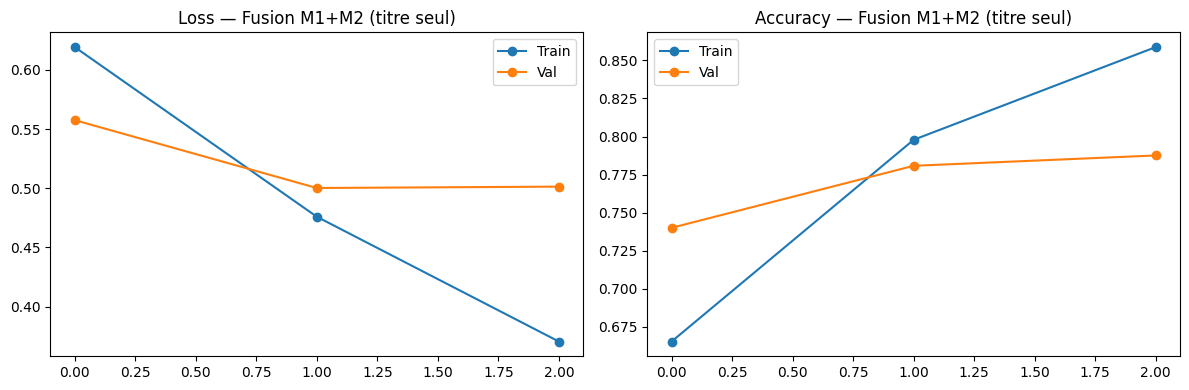

Modèle sauvegardé dans 'fusion_m1_m2_title.pt'

TABLEAU COMPARATIF — GossipCop équilibré (titre seul)
Modèle                                   Accuracy       F1      AUC
--------------------------------------------------------------------
BERT+Source M1+M2 (titre seul, dim=4)      0.7876   0.7874   0.8678


In [3]:
# ============================================================
# MODULE 2 — SCORING DE FIABILITÉ DES SOURCES
# VERSION TITRE SEUL — Vecteur [4]
# [mbfc_score, ratio_uppercase, exclamation_score, sensational_score]
# ============================================================

import pandas as pd
import numpy as np
import re
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertModel
from transformers import get_linear_schedule_with_warmup
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score,
                             roc_auc_score, classification_report)
import matplotlib.pyplot as plt
import seaborn as sns
from urllib.parse import urlparse

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Appareil utilisé : {device}")

from google.colab import drive
drive.mount('/content/drive')


# ============================================================
# BASE DE CRÉDIBILITÉ MBFC
# ============================================================

MBFC_CREDIBILITY_DB = {
    "reuters.com":          {"score": 0.95, "bias": "center",        "category": "reliable"},
    "apnews.com":           {"score": 0.95, "bias": "center",        "category": "reliable"},
    "bbc.com":              {"score": 0.90, "bias": "center-left",   "category": "reliable"},
    "theguardian.com":      {"score": 0.85, "bias": "center-left",   "category": "reliable"},
    "nytimes.com":          {"score": 0.85, "bias": "center-left",   "category": "reliable"},
    "washingtonpost.com":   {"score": 0.85, "bias": "center-left",   "category": "reliable"},
    "npr.org":              {"score": 0.88, "bias": "center-left",   "category": "reliable"},
    "politifact.com":       {"score": 0.92, "bias": "center",        "category": "fact-checker"},
    "snopes.com":           {"score": 0.90, "bias": "center-left",   "category": "fact-checker"},
    "usatoday.com":         {"score": 0.80, "bias": "center",        "category": "reliable"},
    "cbsnews.com":          {"score": 0.82, "bias": "center-left",   "category": "reliable"},
    "nbcnews.com":          {"score": 0.80, "bias": "center-left",   "category": "reliable"},
    "abcnews.go.com":       {"score": 0.80, "bias": "center-left",   "category": "reliable"},
    "foxnews.com":          {"score": 0.45, "bias": "right",         "category": "mixed"},
    "dailymail.co.uk":      {"score": 0.40, "bias": "right",         "category": "mixed"},
    "nypost.com":           {"score": 0.42, "bias": "right-center",  "category": "mixed"},
    "huffpost.com":         {"score": 0.55, "bias": "left",          "category": "mixed"},
    "salon.com":            {"score": 0.50, "bias": "left",          "category": "mixed"},
    "thehill.com":          {"score": 0.65, "bias": "center",        "category": "mixed"},
    "breitbart.com":        {"score": 0.10, "bias": "extreme-right", "category": "fake"},
    "infowars.com":         {"score": 0.05, "bias": "extreme-right", "category": "fake"},
    "naturalnews.com":      {"score": 0.05, "bias": "extreme-right", "category": "fake"},
    "beforeitsnews.com":    {"score": 0.08, "bias": "conspiracy",    "category": "fake"},
    "worldnewsdailyreport.com": {"score": 0.02, "bias": "fake",     "category": "fake"},
    "empirenews.net":       {"score": 0.03, "bias": "fake",          "category": "fake"},
    "abcnews.com.co":       {"score": 0.02, "bias": "fake",          "category": "fake"},
    "politicot.com":        {"score": 0.05, "bias": "fake",          "category": "fake"},
    "newslo.com":           {"score": 0.08, "bias": "fake",          "category": "fake"},
    "thelastlineofdefense.org": {"score": 0.03, "bias": "fake",     "category": "fake"},
}

DEFAULT_INFO = {"score": 0.5, "bias": "unknown", "category": "unknown"}


# ============================================================
# FONCTIONS UTILITAIRES
# ============================================================

def extract_domain(url_or_source):
    if not isinstance(url_or_source, str):
        return "unknown"
    try:
        url_or_source = url_or_source.strip()
        if url_or_source.startswith("http"):
            parsed = urlparse(url_or_source)
            domain = parsed.netloc.replace("www.", "")
            return domain if domain else "unknown"
        if "." in url_or_source:
            return url_or_source.replace("www.", "")
        return url_or_source
    except:
        return "unknown"


def get_mbfc_score(domain):
    domain = domain.lower().strip()
    if domain in MBFC_CREDIBILITY_DB:
        return MBFC_CREDIBILITY_DB[domain]
    for known_domain, info in MBFC_CREDIBILITY_DB.items():
        if known_domain in domain or domain in known_domain:
            return info
    return DEFAULT_INFO


# ============================================================
# FEATURES COMPORTEMENTALES — TITRE SEUL
# ✅ Suppression de external_links (nécessitait le texte)
# ============================================================

SENSATIONAL_WORDS = [
    "shocking", "unbelievable", "breaking", "exclusive", "bombshell",
    "outrage", "scandal", "exposed", "revealed", "secret", "conspiracy",
    "urgent", "alert", "warning", "crisis", "disaster", "chaos",
    "incredible", "stunning", "explosive", "miracle", "banned",
    "censored", "truth", "wake up", "they don't want you to know"
]

def compute_behavioral_features_title_only(title):
    """
    Calcule 3 features comportementales à partir du TITRE SEUL.

    ✅ VERSION TITRE SEUL — 3 features :
        - ratio_uppercase   : proportion de majuscules (sensationnalisme)
        - exclamation_score : densité de ! et ? dans le titre
        - sensational_score : proportion de mots "choc"

    external_links absent (nécessite le texte complet)
    """
    if not isinstance(title, str):
        title = ""

    # --- Feature 1 : Ratio majuscules ---
    nb_upper   = sum(1 for c in title if c.isupper())
    nb_letters = sum(1 for c in title if c.isalpha())
    ratio_uppercase = nb_upper / nb_letters if nb_letters > 0 else 0.0

    # --- Feature 2 : Densité d'exclamations ---
    nb_excl  = title.count("!") + title.count("?")
    nb_words = len(title.split())
    exclamation_score = nb_excl / nb_words if nb_words > 0 else 0.0

    # --- Feature 3 : Mots sensationnels ---
    title_lower = title.lower()
    nb_sensational = sum(
        1 for word in SENSATIONAL_WORDS
        if word in title_lower
    )
    sensational_score = nb_sensational / len(SENSATIONAL_WORDS)

    return {
        "ratio_uppercase":   round(ratio_uppercase,   4),
        "exclamation_score": round(exclamation_score, 4),
        "sensational_score": round(sensational_score, 4),
    }


# ============================================================
# VECTEUR SOURCE FINAL — 4 DIMENSIONS
# ✅ [mbfc_score, ratio_uppercase, exclamation_score, sensational_score]
# ============================================================

def compute_source_vector(domain_or_url, title):
    """
    Produit un vecteur source de 4 dimensions (titre seul).

    Paramètres :
        domain_or_url : str → URL ou domaine de la source
        title         : str → Titre de l'article

    Retourne :
        np.array de shape (4,) :
        [mbfc_score, ratio_uppercase, exclamation_score, sensational_score]
    """
    # Score MBFC
    domain    = extract_domain(domain_or_url)
    mbfc_info = get_mbfc_score(domain)
    mbfc_score = mbfc_info["score"]

    # Features comportementales (titre seul)
    behav = compute_behavioral_features_title_only(title)

    # ✅ Vecteur de 4 dimensions (plus de external_links)
    source_vector = np.array([
        mbfc_score,                     # dim 1 : crédibilité historique
        behav["ratio_uppercase"],       # dim 2 : majuscules
        behav["exclamation_score"],     # dim 3 : exclamations
        behav["sensational_score"],     # dim 4 : mots choc
    ], dtype=np.float32)

    return source_vector, mbfc_info, behav


# ============================================================
# CHARGEMENT DU DATASET
# ============================================================

def load_fakenewsnet_fixed(filepath):
    """
    Charge le dataset et calcule les vecteurs sources [4].
    Travaille uniquement avec le titre.
    """
    df = pd.read_csv(filepath)
    print(f"Colonnes : {df.columns.tolist()}")

    # Extraction domaine si absent
    if 'domain' not in df.columns:
        def extr_domain(url):
            try:
                url = str(url).strip()
                if not url.startswith('http'):
                    url = 'http://' + url
                d = urlparse(url).netloc.replace('www.', '').strip()
                return d if d and d != 'nan' else 'unknown'
            except:
                return 'unknown'
        df['domain'] = df['url'].apply(extr_domain)
        print("✅ Colonne 'domain' créée depuis 'url'")

    # Nettoyage
    df['title']  = df['title'].fillna('')
    df['domain'] = df['domain'].fillna('unknown').replace('nan', 'unknown')
    df['label']  = df['label'].astype(int)
    df = df.dropna(subset=['label']).reset_index(drop=True)

    # ✅ Contenu = titre seul pour BERT
    texts   = df['title'].tolist()
    labels  = df['label'].tolist()
    domains = df['domain'].tolist()
    titles  = df['title'].tolist()

    # Calcul des vecteurs sources [4]
    print("Calcul des vecteurs sources (Module 2 — titre seul)...")
    source_vectors = []
    for domain, title in zip(domains, titles):
        vec, _, _ = compute_source_vector(domain, title)  # ✅ 2 args
        source_vectors.append(vec)
    source_vectors = np.vstack(source_vectors)  # (N, 4)

    print(f"Dataset chargé      : {len(texts)} articles")
    print(f"Vecteurs sources    : {source_vectors.shape}")  # (N, 4)
    print(f"Distribution labels : {pd.Series(labels).value_counts().to_dict()}")
    print(f"Top domaines        : {pd.Series(domains).value_counts().head(5).to_dict()}")

    return texts, source_vectors, labels


# ============================================================
# DATASET PYTORCH
# ============================================================

class HybridDataset(Dataset):
    def __init__(self, texts, source_vectors, labels, tokenizer, max_length=128):
        self.texts          = texts
        self.source_vectors = source_vectors
        self.labels         = labels
        self.tokenizer      = tokenizer
        self.max_length     = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'source_vector':  torch.tensor(
                                self.source_vectors[idx], dtype=torch.float32),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long)
        }


# ============================================================
# MODÈLE HYBRIDE
# ✅ source_dim=4 (au lieu de 5)
# ============================================================

class HybridFakeNewsDetector(nn.Module):
    def __init__(self, bert_model_name='bert-base-uncased',
                 source_dim=4,        #  4 dimensions
                 hidden_dim=256,
                 num_classes=2,
                 dropout=0.3):
        super(HybridFakeNewsDetector, self).__init__()

        self.bert       = BertModel.from_pretrained(bert_model_name)
        bert_hidden     = self.bert.config.hidden_size  # 768

        # Encodeur source : [4] → [32]
        self.source_encoder = nn.Sequential(
            nn.Linear(source_dim, 32),   # ✅ 4 → 32
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 32),
            nn.ReLU()
        )

        # Fusion : 768 + 32 = 800
        self.classifier = nn.Sequential(
            nn.Linear(bert_hidden + 32, hidden_dim),  # 800 → 256
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 64),                # 256 → 64
            nn.ReLU(),
            nn.Dropout(dropout / 2),
            nn.Linear(64, num_classes)                # 64 → 2
        )

    def forward(self, input_ids, attention_mask, source_vector):
        bert_out       = self.bert(input_ids=input_ids,
                                   attention_mask=attention_mask)
        cls_vector     = bert_out.last_hidden_state[:, 0, :]  # (batch, 768)
        source_encoded = self.source_encoder(source_vector)    # (batch, 32)
        fused          = torch.cat([cls_vector, source_encoded], dim=1)
        return self.classifier(fused)


# ============================================================
# ENTRAÎNEMENT ET ÉVALUATION
# ============================================================

def train_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss, all_preds, all_labels = 0, [], []
    criterion = nn.CrossEntropyLoss()

    for batch in loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        source_vector  = batch['source_vector'].to(device)
        labels         = batch['label'].to(device)

        optimizer.zero_grad()
        logits = model(input_ids, attention_mask, source_vector)
        loss   = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        all_preds.extend(torch.argmax(logits, 1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    return total_loss / len(loader), accuracy_score(all_labels, all_preds)


def evaluate(model, loader, device):
    model.eval()
    total_loss, all_preds, all_labels, all_probs = 0, [], [], []
    criterion = nn.CrossEntropyLoss()

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            source_vector  = batch['source_vector'].to(device)
            labels         = batch['label'].to(device)

            logits = model(input_ids, attention_mask, source_vector)
            loss   = criterion(logits, labels)
            total_loss += loss.item()

            all_probs.extend(torch.softmax(logits, 1)[:, 1].cpu().numpy())
            all_preds.extend(torch.argmax(logits, 1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average='weighted')
    auc = roc_auc_score(all_labels, all_probs)
    return total_loss / len(loader), acc, f1, auc, all_preds, all_labels


# ============================================================
# PIPELINE PRINCIPALE
# ============================================================

DATASET_PATH  = '/content/drive/MyDrive/fakenewsnet_gossipcop_balanced.csv'
# DATASET_PATH  = '/content/drive/MyDrive/politifact_titre_balanced.csv'
MAX_LENGTH    = 128
BATCH_SIZE    = 16
EPOCHS        = 3
LEARNING_RATE = 2e-5

# Chargement
texts, source_vectors, labels = load_fakenewsnet_fixed(DATASET_PATH)
print(f"\nDimension vecteur source : {source_vectors.shape[1]}")  # doit afficher 4

# Split
(train_texts, test_texts,
 train_src,   test_src,
 train_labels, test_labels) = train_test_split(
    texts, source_vectors, labels,
    test_size=0.2, random_state=42, stratify=labels
)
print(f"Train : {len(train_texts)} | Test : {len(test_texts)}")

# Tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Datasets et Dataloaders
train_dataset = HybridDataset(train_texts, train_src,  train_labels, tokenizer, MAX_LENGTH)
test_dataset  = HybridDataset(test_texts,  test_src,   test_labels,  tokenizer, MAX_LENGTH)
train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader   = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

# Modèle — ✅ source_dim=4
model = HybridFakeNewsDetector(source_dim=4).to(device)
print(f"Paramètres du modèle : {sum(p.numel() for p in model.parameters()):,}")

# Optimiseur
optimizer   = AdamW(model.parameters(), lr=LEARNING_RATE)
total_steps = len(train_loader) * EPOCHS
scheduler   = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=total_steps // 10,
    num_training_steps=total_steps
)

# Entraînement
print("\n=== ENTRAÎNEMENT FUSION MODULE 1 + MODULE 2 (titre seul) ===\n")
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_f1 = 0

for epoch in range(EPOCHS):
    print(f"--- Époque {epoch+1}/{EPOCHS} ---")
    train_loss, train_acc = train_epoch(
        model, train_loader, optimizer, scheduler, device)
    val_loss, val_acc, val_f1, val_auc, _, _ = evaluate(
        model, test_loader, device)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"Train → Loss: {train_loss:.4f} | Acc: {train_acc:.4f}")
    print(f"Test  → Loss: {val_loss:.4f}  | Acc: {val_acc:.4f} | "
          f"F1: {val_f1:.4f} | AUC: {val_auc:.4f}")

    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(model.state_dict(), 'best_fusion_m1_m2_title.pt')
        print(f"  ✅ Meilleur modèle sauvegardé (F1={best_f1:.4f})\n")
    else:
        print()

# Évaluation finale
print("\n=== ÉVALUATION FINALE ===\n")
_, acc, f1, auc, preds, true_labels = evaluate(model, test_loader, device)
print(classification_report(true_labels, preds, target_names=['Réel', 'Fake']))
print(f"Accuracy : {acc:.4f} | F1 : {f1:.4f} | AUC : {auc:.4f}")

# Courbes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history['train_loss'], label='Train', marker='o')
ax1.plot(history['val_loss'],   label='Val',   marker='o')
ax1.set_title('Loss — Fusion M1+M2 (titre seul)') ; ax1.legend()
ax2.plot(history['train_acc'], label='Train', marker='o')
ax2.plot(history['val_acc'],   label='Val',   marker='o')
ax2.set_title('Accuracy — Fusion M1+M2 (titre seul)') ; ax2.legend()
plt.tight_layout()
plt.savefig('fusion_m1_m2_title_only.png', dpi=120)
plt.show()

# Sauvegarde
torch.save(model.state_dict(), 'fusion_m1_m2_title.pt')
tokenizer.save_pretrained('./tokenizer_m1_m2_title')
print("Modèle sauvegardé dans 'fusion_m1_m2_title.pt'")

# Tableau récapitulatif
print("\n" + "="*68)
print("TABLEAU COMPARATIF — GossipCop équilibré (titre seul)")
print("="*68)
print(f"{'Modèle':<38} {'Accuracy':>10} {'F1':>8} {'AUC':>8}")
print("-"*68)
# print(f"{'TF-IDF+SVM V1 (titre seul)':<38} {'0.7876':>10} {'0.7875':>8} {'0.8599':>8}")
# print(f"{'TF-IDF+SVM V2 (titre+texte)':<38} {'0.8293':>10} {'0.8293':>8} {'0.9066':>8}")
print(f"{'BERT+Source M1+M2 (titre seul, dim=4)':<38} {acc:>10.4f} {f1:>8.4f} {auc:>8.4f}")
# print(f"{'BERT+Source+KG M1+M2+M3':<38} {'⏳':>10} {'⏳':>8} {'⏳':>8}")
print("="*68)